<a href="https://colab.research.google.com/github/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/blob/main/PERFORMANCE_DECISION__TREE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entropy calculation

In [ ]:
#p1=0.5 and p2=0.5
import math
entropy=-0.5*math.log2(0.5) -0.5*math.log2(0.5)
print("Entropy for 50%-50% case ==>", entropy)

Entropy for 50%-50% case ==> 1.0


In [ ]:
entropy=-0.0001*math.log2(0.0001) -0.9999*math.log2(0.9999)
print("Entropy for 0%-100% case ==>", entropy)

Entropy for 0%-100% case ==> 0.0014730335283281598


In [ ]:
import math
entropy=-0.45*math.log2(0.45) -0.55*math.log2(0.55)
print("Entropy for 45%-55% case ==>", entropy)

entropy=-0.05*math.log2(0.05) -0.95*math.log2(0.95)
print("Entropy for 5%-95% case ==>", entropy)

Entropy for 45%-55% case ==> 0.9927744539878083
Entropy for 5%-95% case ==> 0.28639695711595625


# Data Importing

In [ ]:
#Import Data
import pandas as pd

Ecom_data = pd.read_csv("https://raw.githubusercontent.com/cmvigneswaranaero-gif/ML-DL/refs/heads/main/decision_tree_Ecom_Cust_Survey_v1.csv")

Ecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11805 entries, 0 to 11804
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Cust_num              11805 non-null  int64 
 1   Region                11805 non-null  int64 
 2   Age                   11805 non-null  int64 
 3   Order_Quantity        11805 non-null  int64 
 4   Customer_Type         11805 non-null  object
 5   Overall_Satisfaction  11805 non-null  object
dtypes: int64(4), object(2)
memory usage: 553.5+ KB


In [ ]:
Ecom_data['Overall_Satisfaction'].value_counts()

,count
Overall_Satisfaction,
Dis Satisfied,6408
Satisfied,5397


# Convert Non-numerical Data into numerical

In [ ]:
Ecom_data['Customer_Type_num'] = Ecom_data['Customer_Type'].map({'Prime': 1, 'Non_Prime': 0}).astype(int)
print(Ecom_data['Customer_Type'].value_counts())
print(Ecom_data['Customer_Type_num'].value_counts())

Customer_Type
Prime        6804
Non_Prime    5001
Name: count, dtype: int64
Customer_Type_num
1    6804
0    5001
Name: count, dtype: int64


In [ ]:
Ecom_data['Overall_Satisfaction_num'] = Ecom_data['Overall_Satisfaction'].map( {'Dis Satisfied': 0, 'Satisfied': 1} ).astype(int).astype(int)
print(Ecom_data['Overall_Satisfaction'].value_counts())
print(Ecom_data['Overall_Satisfaction_num'].value_counts())

Overall_Satisfaction
Dis Satisfied    6408
Satisfied        5397
Name: count, dtype: int64
Overall_Satisfaction_num
0    6408
1    5397
Name: count, dtype: int64


In [ ]:
Ecom_data.columns

Index(['Cust_num', 'Region', 'Age', 'Order_Quantity', 'Customer_Type',
       'Overall_Satisfaction', 'Customer_Type_num',
       'Overall_Satisfaction_num'],
      dtype='object')

# Decision Tree Model Building

In [ ]:
from sklearn import tree

features= ['Region', 'Age', 'Order_Quantity',  'Customer_Type_num']
print("Features",features)

X = Ecom_data[features]
print("X shape", X.shape)
y = Ecom_data['Overall_Satisfaction']
print("Y shape", y.shape)

Features ['Region', 'Age', 'Order_Quantity', 'Customer_Type_num']
X shape (11805, 4)
Y shape (11805,)


|--- Order_Quantity <= 40.50
|   |--- Age <= 29.50
|   |   |--- class: Satisfied
|   |--- Age >  29.50
|   |   |--- class: Dis Satisfied
|--- Order_Quantity >  40.50
|   |--- Age <= 20.50
|   |   |--- class: Satisfied
|   |--- Age >  20.50
|   |   |--- class: Satisfied



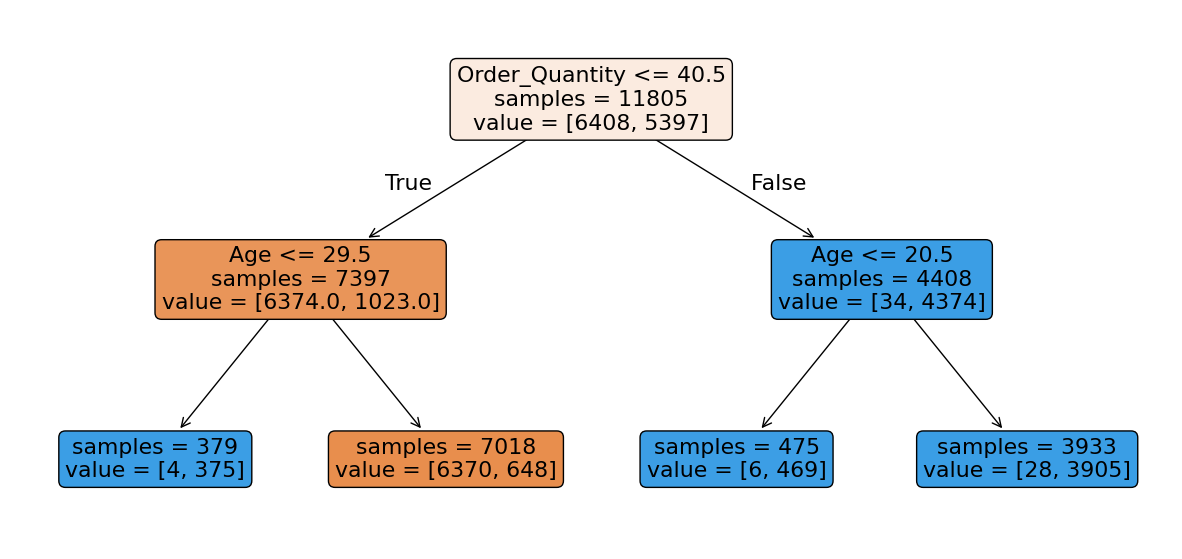

In [ ]:
#Building Tree Model

DTree = tree.DecisionTreeClassifier(max_depth=2)
DTree.fit(X,y)

##Plotting the trees
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
plt.figure(figsize=(15,7))
plot_tree(DTree, filled=True,
                     rounded=True,
                     impurity=False,
                     feature_names = features)
print( export_text(DTree, feature_names = features))


[Text(0.5, 0.8333333333333334, 'x[2] <= 40.5\ngini = 0.496\nsamples = 11805\nvalue = [6408, 5397]'),
 Text(0.25, 0.5, 'x[1] <= 29.5\ngini = 0.238\nsamples = 7397\nvalue = [6374.0, 1023.0]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.021\nsamples = 379\nvalue = [4, 375]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.168\nsamples = 7018\nvalue = [6370, 648]'),
 Text(0.75, 0.5, 'x[1] <= 20.5\ngini = 0.015\nsamples = 4408\nvalue = [34, 4374]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.025\nsamples = 475\nvalue = [6, 469]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.014\nsamples = 3933\nvalue = [28, 3905]')]

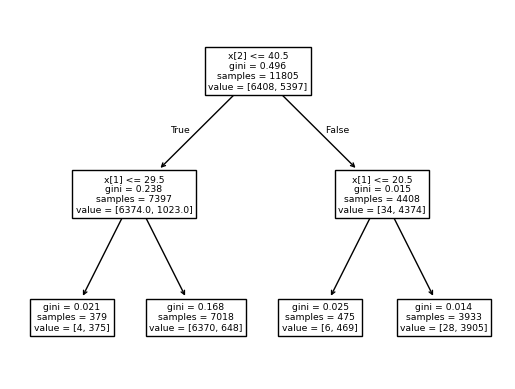

In [ ]:
# this code for ploting tree with only dtree command
DTree = tree.DecisionTreeClassifier(max_depth=2)
DTree.fit(X, y)
##Plotting the trees

plot_tree(DTree)

[Text(0.5, 0.8333333333333334, 'x[2] <= 40.5\nentropy = 0.995\nsamples = 11805\nvalue = [6408, 5397]'),
 Text(0.25, 0.5, 'x[1] <= 29.5\nentropy = 0.58\nsamples = 7397\nvalue = [6374.0, 1023.0]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 0.084\nsamples = 379\nvalue = [4, 375]'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.444\nsamples = 7018\nvalue = [6370, 648]'),
 Text(0.75, 0.5, 'x[2] <= 67.5\nentropy = 0.065\nsamples = 4408\nvalue = [34, 4374]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.078\nsamples = 1990\nvalue = [19, 1971]'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.054\nsamples = 2418\nvalue = [15.0, 2403.0]')]

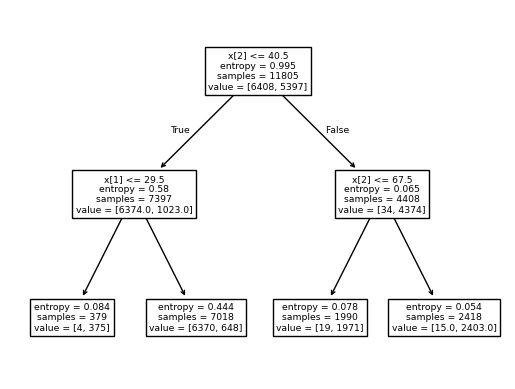

In [ ]:
# this code for plooting tre without gini
DTree = tree.DecisionTreeClassifier(criterion="entropy", max_depth=2)
DTree.fit(X, y)
##Plotting the trees

plot_tree(DTree)

# Tree Validation

In [ ]:
##########Tree Validation
#Tree Validation
from sklearn.metrics import accuracy_score

predict1 = DTree.predict(X)

from sklearn.metrics import confusion_matrix ###for using confusion matrix###
cm = confusion_matrix(y, predict1)
print (cm)


total = sum(sum(cm))
#####from confusion matrix calculate accuracy
accuracy = (cm[0,0]+cm[1,1])/total
print(accuracy)


# instead of doing this in manual way, we can predict directly accuracy score
print("\nTraining Accuracy:", accuracy_score(y, predict1))

[[6370   38]
 [ 648 4749]]
0.9418890300720034

Training Accuracy: 0.9418890300720034


In [ ]:
# cant belive this validation so train and test data
#if train and test accuracy are same ..good..or if train more and test less
# overfiting
from sklearn.model_selection import train_test_split

# --------------------------
# 1. Train-Test Split (80%-20%)
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --------------------------
# 2. Build & Train Decision Tree
# --------------------------
DTree = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
DTree.fit(X_train, y_train)

# --------------------------
# 3. Predictions for Train & Test
# --------------------------
y_train_pred = DTree.predict(X_train)
y_test_pred = DTree.predict(X_test)

# --------------------------
# 4. Confusion Matrix for Training Data
# --------------------------
cm_train = confusion_matrix(y_train, y_train_pred)
print("\nTraining Confusion Matrix:\n", cm_train)

# --------------------------
# 5. Confusion Matrix for Testing Data
# --------------------------
cm_test = confusion_matrix(y_test, y_test_pred)
print("\nTesting Confusion Matrix:\n", cm_test)

# --------------------------
# 6. Accuracy & Reports
# --------------------------
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))




Training Confusion Matrix:
 [[5096   35]
 [ 526 3787]]

Testing Confusion Matrix:
 [[1274    3]
 [ 122  962]]

Training Accuracy: 0.9405972045743329
Testing Accuracy: 0.9470563320626854


# The problem of overfitting

In [ ]:
# change max depth
# 1. Train-Test Split (80%-20%)
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --------------------------
# 2. Build & Train Decision Tree
# --------------------------
DTree = tree.DecisionTreeClassifier(max_depth=3000, random_state=42)
DTree.fit(X_train, y_train)

# --------------------------
# 3. Predictions for Train & Test
# --------------------------
y_train_pred = DTree.predict(X_train)
y_test_pred = DTree.predict(X_test)

# --------------------------
# 4. Confusion Matrix for Training Data
# --------------------------
cm_train = confusion_matrix(y_train, y_train_pred)
print("\nTraining Confusion Matrix:\n", cm_train)

# --------------------------
# 5. Confusion Matrix for Testing Data
# --------------------------
cm_test = confusion_matrix(y_test, y_test_pred)
print("\nTesting Confusion Matrix:\n", cm_test)

# --------------------------
# 6. Accuracy & Reports
# --------------------------
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))


Training Confusion Matrix:
 [[5096   35]
 [ 221 4092]]

Testing Confusion Matrix:
 [[1214   63]
 [  99  985]]

Training Accuracy: 0.9728928420160948
Testing Accuracy: 0.9313850063532402


***example 2 for overfitting***



In [ ]:
#Datasets: Diabetes
#Import both test and training data

train = pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/pima/diabetes_train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/pima/diabetes_test.csv")

print(train.sample(5))

     Count_Pregnancies  Glucose_level  BP  SkinThickness_index  Insulin_level  \
161                 10            162  84                    0              0   
541                  8            143  66                    0              0   
553                  2             89  90                   30              0   
88                   0            102  86                   17            105   
246                  4             99  68                   38              0   

      BMI  DiabetesPedigreeFunction  Age  Diabetes_outcome  
161  27.7                     0.182   54                 0  
541  34.9                     0.129   41                 1  
553  33.5                     0.292   42                 0  
88   29.3                     0.695   27                 0  
246  32.8                     0.145   33                 0  


In [ ]:
from sklearn import tree

#Defining Features and lables
features=['Count_Pregnancies', 'Glucose_level', 'BP', 'SkinThickness_index',
          'Insulin_level', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X_train = train[features]
y_train = train['Diabetes_outcome']

#X_train

X_test = test[features]
y_test = test['Diabetes_outcome']

In [ ]:
#training Tree Model
clf = tree.DecisionTreeClassifier() # this automatically take infinity
clf.fit(X_train,y_train)

predict1 = clf.predict(X_train)
predict2 = clf.predict(X_test)

#On Train Data
cm1 = confusion_matrix(y_train,predict1)
print("\nTraining Confusion Matrix:\n", cm1)
print("\nTraining Accuracy:", accuracy_score(y_train,predict1))

#On Test Data
cm2 = confusion_matrix(y_test,predict2)
print("\nTesting Confusion Matrix:\n", cm2)
print("Testing Accuracy:", accuracy_score(y_test,predict2))


Training Confusion Matrix:
 [[410   0]
 [  0 204]]

Training Accuracy: 1.0

Testing Confusion Matrix:
 [[75 15]
 [25 39]]
Testing Accuracy: 0.7402597402597403


# Pruning

## max_leaf_nodes - Finetuning

In [ ]:
#training Tree Model
clf = tree.DecisionTreeClassifier(max_leaf_nodes = 3000)
clf.fit(X_train,y_train)

predict1 = clf.predict(X_train)
predict2 = clf.predict(X_test)

#On Train Data
cm1 = confusion_matrix(y_train,predict1)
print("\nTraining Confusion Matrix:\n", cm1)
print("\nTraining Accuracy:", accuracy_score(y_train,predict1))

#On Test Data
cm2 = confusion_matrix(y_test,predict2)
print("\nTesting Confusion Matrix:\n", cm2)
print("Testing Accuracy:", accuracy_score(y_test,predict2))


Training Confusion Matrix:
 [[410   0]
 [  0 204]]

Training Accuracy: 1.0

Testing Confusion Matrix:
 [[76 14]
 [25 39]]
Testing Accuracy: 0.7467532467532467


In [ ]:
#training Tree Model
clf = tree.DecisionTreeClassifier(max_leaf_nodes = 30)
clf.fit(X_train,y_train)

predict1 = clf.predict(X_train)
predict2 = clf.predict(X_test)

#On Train Data
cm1 = confusion_matrix(y_train,predict1)
print("\nTraining Confusion Matrix:\n", cm1)
print("\nTraining Accuracy:", accuracy_score(y_train,predict1))

#On Test Data
cm2 = confusion_matrix(y_test,predict2)
print("\nTesting Confusion Matrix:\n", cm2)
print("Testing Accuracy:", accuracy_score(y_test,predict2))


Training Confusion Matrix:
 [[378  32]
 [ 46 158]]

Training Accuracy: 0.8729641693811075

Testing Confusion Matrix:
 [[82  8]
 [24 40]]
Testing Accuracy: 0.7922077922077922


In [ ]:
#training Tree Model
clf = tree.DecisionTreeClassifier(max_leaf_nodes = 10)
clf.fit(X_train,y_train)

predict1 = clf.predict(X_train)
predict2 = clf.predict(X_test)

#On Train Data
cm1 = confusion_matrix(y_train,predict1)
print("\nTraining Confusion Matrix:\n", cm1)
print("\nTraining Accuracy:", accuracy_score(y_train,predict1))

#On Test Data
cm2 = confusion_matrix(y_test,predict2)
print("\nTesting Confusion Matrix:\n", cm2)
print("Testing Accuracy:", accuracy_score(y_test,predict2))


Training Confusion Matrix:
 [[366  44]
 [ 74 130]]

Training Accuracy: 0.8078175895765473

Testing Confusion Matrix:
 [[86  4]
 [30 34]]
Testing Accuracy: 0.7792207792207793
